# Total Fixations (Overall) Analysis


## Preprocessing
Required Imports

In [12]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


Useful functions

In [13]:
def filter_by_polarity(df):
    '''
    Function to filter the DataFrame by polarity (claro and oscuro)

    There must be a column named Timeline with the values 'Timeline1-Mode1' for claro and 'Timeline2-Mode2' for oscuro
    '''
    claro = df[df['Timeline'] == 'Timeline1-Mode1'] 
    oscuro = df[df['Timeline'] == 'Timeline2-Mode2'] 
    return claro, oscuro

def obtain_basic_data(array):
    mean = np.mean(array)
    
    std = np.std(array)
    max = np.max(array)
    min = np.min(array)
    return mean, std, max, min

def separate_by_toi(df, toi):
    '''
    Function to obtain Patata, Mochila, Text and Entire Recording

    There must be a column named 'TOI' 
    '''
    df_toi = df[df['TOI'] == toi]
    return df_toi

First Pandas dataset

In [14]:
tf = pd.read_csv('raw/TotalFixations.tsv', sep='\t')

tf_claro, tf_oscuro = filter_by_polarity(tf)


tf_claro_patata = separate_by_toi(tf_claro, 'PatataClaro')
tf_oscuro_patata = separate_by_toi(tf_oscuro, 'PatataOscuro')

tf_claro_mochila = separate_by_toi(tf_claro, 'MochilaClaro')
tf_oscuro_mochila = separate_by_toi(tf_oscuro, 'MochilaOscuro')

tf_claro_entire = separate_by_toi(tf_claro, 'Entire Recording')
tf_oscuro_entire = separate_by_toi(tf_oscuro, 'Entire Recording')

def run_function_on_totalfixations(df, func):
    '''Runs the given function on the specified columns of the dataframe'''
    return func(df['Total_duration_of_whole_fixations']),func(df['Number_of_whole_fixations']),func(df['Duration_of_first_whole_fixation']),func(df['Average_duration_of_whole_fixations'])


## Processing
### Basics

In [15]:
basic_data = {
    'PatataClaro': run_function_on_totalfixations(tf_claro_patata, obtain_basic_data),
    'PatataOscuro': run_function_on_totalfixations(tf_oscuro_patata, obtain_basic_data),
    'MochilaClaro': run_function_on_totalfixations(tf_claro_mochila, obtain_basic_data),
    'MochilaOscuro': run_function_on_totalfixations(tf_oscuro_mochila, obtain_basic_data),
    'EntireClaro': run_function_on_totalfixations(tf_claro_entire, obtain_basic_data),
    'EntireOscuro': run_function_on_totalfixations(tf_oscuro_entire, obtain_basic_data),
}
def basic_data_to_string(basic_data):
    return " - [Mean: {:.2f}] [Std: {:.2f}] [Max: {:.2f}] [Min: {:.2f}]".format(*basic_data)
    
for key in basic_data:
    print(f"Results for {key}:")
    print("Total_duration_of_whole_fixations", basic_data_to_string(basic_data[key][0]))
    print("Number_of_whole_fixations", basic_data_to_string(basic_data[key][1]))
    print("Duration_of_first_whole_fixation", basic_data_to_string(basic_data[key][2]))
    print("Average_duration_of_whole_fixations", basic_data_to_string(basic_data[key][3]))
    print()

Results for PatataClaro:
Total_duration_of_whole_fixations  - [Mean: 52902.88] [Std: 24410.26] [Max: 125026.00] [Min: 18570.00]
Number_of_whole_fixations  - [Mean: 158.94] [Std: 52.41] [Max: 301.00] [Min: 62.00]
Duration_of_first_whole_fixation  - [Mean: 181.29] [Std: 111.99] [Max: 583.00] [Min: 83.00]
Average_duration_of_whole_fixations  - [Mean: 329.29] [Std: 79.39] [Max: 537.00] [Min: 234.00]

Results for PatataOscuro:
Total_duration_of_whole_fixations  - [Mean: 41879.59] [Std: 17204.72] [Max: 72631.00] [Min: 2631.00]
Number_of_whole_fixations  - [Mean: 142.65] [Std: 50.59] [Max: 208.00] [Min: 13.00]
Duration_of_first_whole_fixation  - [Mean: 205.82] [Std: 100.07] [Max: 533.00] [Min: 100.00]
Average_duration_of_whole_fixations  - [Mean: 287.53] [Std: 57.97] [Max: 441.00] [Min: 202.00]

Results for MochilaClaro:
Total_duration_of_whole_fixations  - [Mean: 64217.12] [Std: 34024.20] [Max: 125642.00] [Min: 9443.00]
Number_of_whole_fixations  - [Mean: 199.06] [Std: 92.76] [Max: 320.00] [

## T-student analysis & Mann-Whitney Test

First, we check the normality of the data

In [16]:

metrics = [
    'Total_duration_of_whole_fixations',
    'Number_of_whole_fixations',
    'Duration_of_first_whole_fixation',
    'Average_duration_of_whole_fixations',
]


def check_normality(df):
    results = {}
    for metric in metrics:
        values = df[metric].dropna()
        w_stat, p_value = stats.shapiro(values)
        print(f"{metric}: Shapiro-Wilk W={w_stat:.4f}, p-value={p_value:.4f}, Normal: {p_value > 0.05}")
        results[metric] = (w_stat, p_value, p_value > 0.05)
    return results

print("Normality check for PatataClaro:")
normal_claro_patata=check_normality(tf_claro_patata)
print("\nNormality check for PatataOscuro:")
normal_oscuro_patata=check_normality(tf_oscuro_patata)
print("\nNormality check for MochilaClaro:")
normal_claro_mochila=check_normality(tf_claro_mochila)
print("\nNormality check for MochilaOscuro:")
normal_oscuro_mochila=check_normality(tf_oscuro_mochila)
print("\nNormality check for EntireClaro:")
normal_claro_entire=check_normality(tf_claro_entire)
print("\nNormality check for EntireOscuro:")
normal_oscuro_entire=check_normality(tf_oscuro_entire)


Normality check for PatataClaro:
Total_duration_of_whole_fixations: Shapiro-Wilk W=0.8454, p-value=0.0091, Normal: False
Number_of_whole_fixations: Shapiro-Wilk W=0.9536, p-value=0.5150, Normal: True
Duration_of_first_whole_fixation: Shapiro-Wilk W=0.6848, p-value=0.0001, Normal: False
Average_duration_of_whole_fixations: Shapiro-Wilk W=0.8837, p-value=0.0365, Normal: False

Normality check for PatataOscuro:
Total_duration_of_whole_fixations: Shapiro-Wilk W=0.9677, p-value=0.7774, Normal: True
Number_of_whole_fixations: Shapiro-Wilk W=0.9278, p-value=0.2003, Normal: True
Duration_of_first_whole_fixation: Shapiro-Wilk W=0.7522, p-value=0.0005, Normal: False
Average_duration_of_whole_fixations: Shapiro-Wilk W=0.9375, p-value=0.2901, Normal: True

Normality check for MochilaClaro:
Total_duration_of_whole_fixations: Shapiro-Wilk W=0.9641, p-value=0.7094, Normal: True
Number_of_whole_fixations: Shapiro-Wilk W=0.9105, p-value=0.1019, Normal: True
Duration_of_first_whole_fixation: Shapiro-Wil

then we analyze

In [17]:
def ttest_independent_samples(df1, df2, metric):
    return stats.ttest_ind(df1[metric], df2[metric], equal_var=False)

def mannWhitney_independent_samples(df1, df2, metric):
    return stats.mannwhitneyu(df1[metric], df2[metric], alternative='two-sided')

patata_tstudent = {}
patata_mann_whitney = {}
mochila_tstudent = {}
mochila_mann_whitney = {}
entire_tstudent = {}
entire_mann_whitney = {}

for metric in metrics:
    print(f"\nRunning tests for metric: {metric}")


    if normal_claro_patata[metric][2] and normal_oscuro_patata[metric][2]:
        result = ttest_independent_samples(tf_claro_patata, tf_oscuro_patata, metric)
        patata_tstudent[metric] = result
        print(f"Patata -> T-test | statistic={result.statistic:.4f}, p-value={result.pvalue:.6f}")
    else:
        result = mannWhitney_independent_samples(tf_claro_patata, tf_oscuro_patata, metric)
        patata_mann_whitney[metric] = result
        print(f"Patata -> Mann-Whitney U | statistic={result.statistic:.4f}, p-value={result.pvalue:.6f}")

    # Mochila
    if normal_claro_mochila[metric][2] and normal_oscuro_mochila[metric][2]:
        result = ttest_independent_samples(tf_claro_mochila, tf_oscuro_mochila, metric)
        mochila_tstudent[metric] = result
        print(f"Mochila -> T-test | statistic={result.statistic:.4f}, p-value={result.pvalue:.6f}")
    else:
        result = mannWhitney_independent_samples(tf_claro_mochila, tf_oscuro_mochila, metric)
        mochila_mann_whitney[metric] = result
        print(f"Mochila -> Mann-Whitney U | statistic={result.statistic:.4f}, p-value={result.pvalue:.6f}")

    # Entire Recording
    if normal_claro_entire[metric][2] and normal_oscuro_entire[metric][2]:
        result = ttest_independent_samples(tf_claro_entire, tf_oscuro_entire, metric)
        entire_tstudent[metric] = result
        print(f"Entire Recording -> T-test | statistic={result.statistic:.4f}, p-value={result.pvalue:.6f}")
    else:
        result = mannWhitney_independent_samples(tf_claro_entire, tf_oscuro_entire, metric)
        entire_mann_whitney[metric] = result
        print(f"Entire Recording -> Mann-Whitney U | statistic={result.statistic:.4f}, p-value={result.pvalue:.6f}") 



Running tests for metric: Total_duration_of_whole_fixations
Patata -> Mann-Whitney U | statistic=178.0000, p-value=0.255690
Mochila -> T-test | statistic=1.0032, p-value=0.324434
Entire Recording -> T-test | statistic=2.5175, p-value=0.017366

Running tests for metric: Number_of_whole_fixations
Patata -> T-test | statistic=0.8947, p-value=0.377622
Mochila -> T-test | statistic=0.1791, p-value=0.859090
Entire Recording -> T-test | statistic=1.8583, p-value=0.073624

Running tests for metric: Duration_of_first_whole_fixation
Patata -> Mann-Whitney U | statistic=115.5000, p-value=0.322402
Mochila -> Mann-Whitney U | statistic=162.5000, p-value=0.543447
Entire Recording -> Mann-Whitney U | statistic=175.0000, p-value=0.300536

Running tests for metric: Average_duration_of_whole_fixations
Patata -> Mann-Whitney U | statistic=186.5000, p-value=0.152793
Mochila -> Mann-Whitney U | statistic=201.5000, p-value=0.051416
Entire Recording -> T-test | statistic=1.4303, p-value=0.162380


Matplotlib results shown

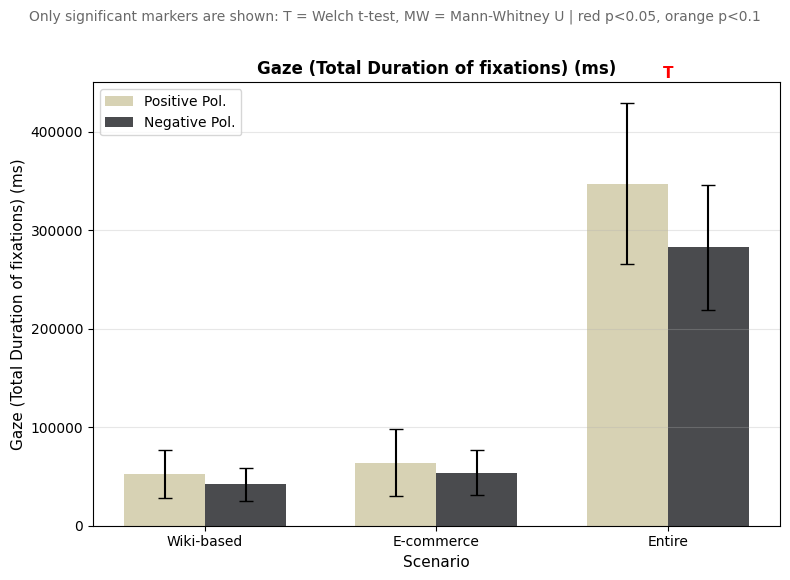

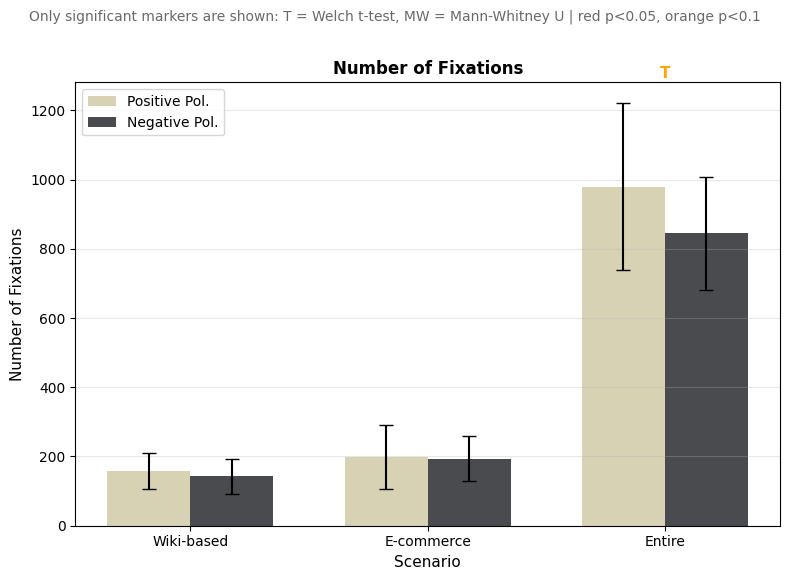

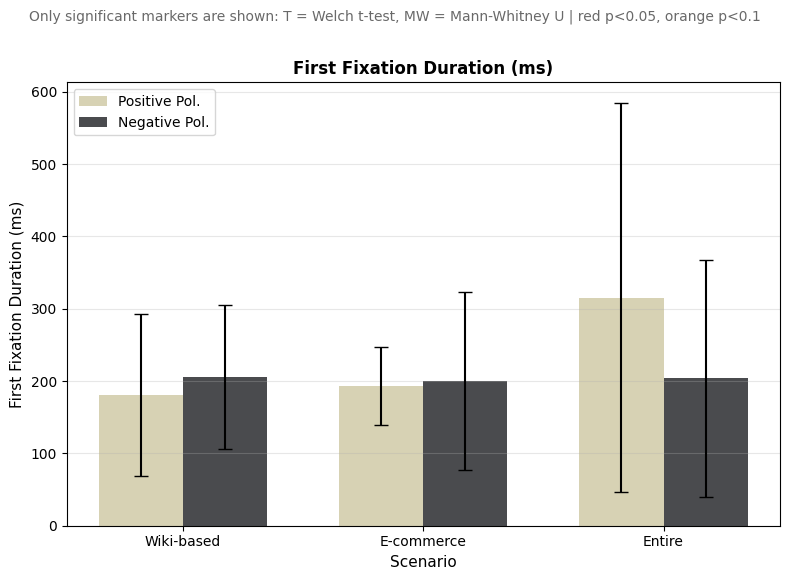

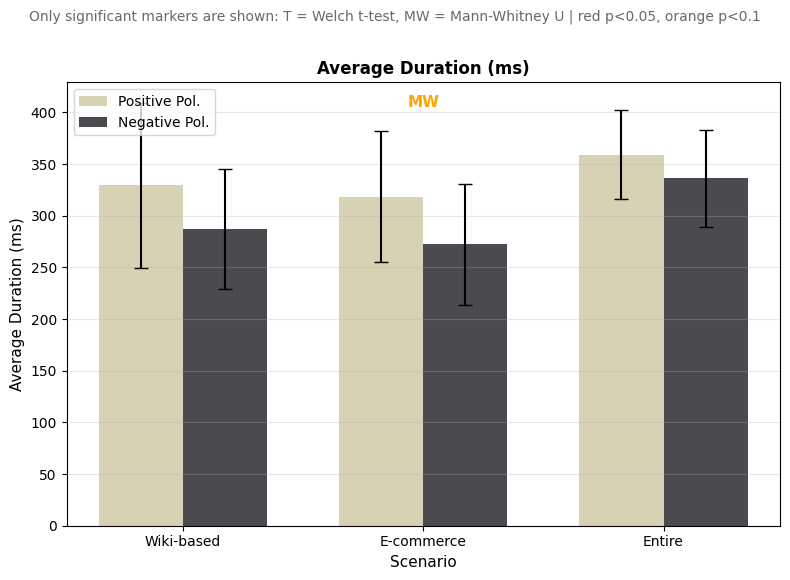

In [18]:
# Github Copilot + some edits from myself from here


metric_keys = [
    'Total_duration_of_whole_fixations',
    'Number_of_whole_fixations',
    'Duration_of_first_whole_fixation',
    'Average_duration_of_whole_fixations',
]

metric_labels = [
    'Gaze (Total Duration of fixations) (ms)',
    'Number of Fixations',
    'First Fixation Duration (ms)',
    'Average Duration (ms)',
]
toi_labels = ['Wiki-based', 'E-commerce', 'Entire']

# Map each scenario to the result dictionaries created in the previous cell
scenario_results = {
    'Wiki-based': {'T': patata_tstudent, 'MW': patata_mann_whitney},
    'E-commerce': {'T': mochila_tstudent, 'MW': mochila_mann_whitney},
    'Entire': {'T': entire_tstudent, 'MW': entire_mann_whitney},
}


# One independent figure per metric so each chart can be copied/exported separately
for idx, metric in enumerate(metric_keys):
    fig, ax = plt.subplots(figsize=(8, 6))

    claro_means = [
        basic_data['PatataClaro'][idx][0],
        basic_data['MochilaClaro'][idx][0],
        basic_data['EntireClaro'][idx][0],
    ]
    claro_stds = [
        basic_data['PatataClaro'][idx][1],
        basic_data['MochilaClaro'][idx][1],
        basic_data['EntireClaro'][idx][1],
    ]
    oscuro_means = [
        basic_data['PatataOscuro'][idx][0],
        basic_data['MochilaOscuro'][idx][0],
        basic_data['EntireOscuro'][idx][0],
    ]
    oscuro_stds = [
        basic_data['PatataOscuro'][idx][1],
        basic_data['MochilaOscuro'][idx][1],
        basic_data['EntireOscuro'][idx][1],
    ]

    x = np.arange(len(toi_labels))
    width = 0.35

    ax.bar(
        x - width / 2,
        claro_means,
        width,
        yerr=claro_stds,
        label='Positive Pol.',
        color='#CEC7A2',
        alpha=0.8,
        capsize=5,
    )
    ax.bar(
        x + width / 2,
        oscuro_means,
        width,
        yerr=oscuro_stds,
        label='Negative Pol.',
        color='#1D1E22',
        alpha=0.8,
        capsize=5,
    )

    # Add marker only when result is relevant/significant (p < 0.1)
    for j, scenario in enumerate(toi_labels):
        y_pos = max(claro_means[j] + claro_stds[j], oscuro_means[j] + oscuro_stds[j])

        if metric in scenario_results[scenario]['T']:
            test_used = 'T'
            pvalue = scenario_results[scenario]['T'][metric].pvalue
        elif metric in scenario_results[scenario]['MW']:
            test_used = 'MW'
            pvalue = scenario_results[scenario]['MW'][metric].pvalue
        else:
            continue

        # Hide labels when not significant/relevant
        if pvalue >= 0.1:
            continue

        color = 'red' if pvalue < 0.05 else 'orange'

        ax.text(
            x[j],
            y_pos * 1.06,
            test_used,
            ha='center',
            fontsize=11,
            fontweight='bold',
            color=color,
        )

    ax.set_xlabel('Scenario', fontsize=11)
    ax.set_ylabel(metric_labels[idx], fontsize=11)
    ax.set_title(metric_labels[idx], fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(toi_labels)
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)

    fig.text(
        0.5,
        0.94,
        'Only significant markers are shown: T = Welch t-test, MW = Mann-Whitney U | red p<0.05, orange p<0.1',
        ha='center',
        fontsize=10,
        color='dimgray',
    )
    plt.tight_layout(rect=[0, 0, 1, 0.90])

    # Pa guardar las fotos
    fig.savefig(f'output/figures/{metric}.png', dpi=300, bbox_inches='tight')

    plt.show()

# END OF GH COPILOT

# Saccades Analysis

In [19]:
sf = pd.read_csv('raw/Saccades.tsv', sep='\t')

metrics = ['Average_peak_velocity_of_saccades', 'Average_amplitude_of_saccades', 'Number_of_saccades','Amplitude_of_first_saccade']

sf['Average_peak_velocity_of_saccades'] = sf['Average_peak_velocity_of_saccades'].str.replace(',', '.').astype(float)
sf['Average_amplitude_of_saccades'] = sf['Average_amplitude_of_saccades'].str.replace(',', '.').astype(float)
sf['Amplitude_of_first_saccade'] = sf['Amplitude_of_first_saccade'].str.replace(',', '.').astype(float)

sf_claro, sf_oscuro = filter_by_polarity(sf)

sf_claro_patata = separate_by_toi(sf_claro, 'PatataClaro')
sf_oscuro_patata = separate_by_toi(sf_oscuro, 'PatataOscuro')

sf_claro_mochila = separate_by_toi(sf_claro, 'MochilaClaro')
sf_oscuro_mochila = separate_by_toi(sf_oscuro, 'MochilaOscuro')

sf_claro_entire = separate_by_toi(sf_claro, 'Entire Recording')
sf_oscuro_entire = separate_by_toi(sf_oscuro, 'Entire Recording')

def run_function_on_dataframe(df, func,params):
    '''Runs the given function on the specified columns of the dataframe'''
    aux = []
    for param in params:
        aux.append(func(df[param]))
    return aux

## Processing
### Basics

In [20]:
basic_data_saccades = {
    'PatataClaro': run_function_on_dataframe(sf_claro_patata, obtain_basic_data, metrics),
    'PatataOscuro': run_function_on_dataframe(sf_oscuro_patata, obtain_basic_data, metrics),
    'MochilaClaro': run_function_on_dataframe(sf_claro_mochila, obtain_basic_data, metrics),
    'MochilaOscuro': run_function_on_dataframe(sf_oscuro_mochila, obtain_basic_data, metrics),
    'EntireClaro': run_function_on_dataframe(sf_claro_entire, obtain_basic_data, metrics),
    'EntireOscuro': run_function_on_dataframe(sf_oscuro_entire, obtain_basic_data, metrics),
}

for key in basic_data_saccades:
    print(f"Results for {key}:")
    print("Average_peak_velocity_of_saccades", basic_data_to_string(basic_data_saccades[key][0]))
    print("Average_amplitude_of_saccades", basic_data_to_string(basic_data_saccades[key][1]))
    print("Number_of_saccades", basic_data_to_string(basic_data_saccades[key][2]))
    print("Amplitude_of_first_saccade", basic_data_to_string(basic_data_saccades[key][3]))
    print() 

Results for PatataClaro:
Average_peak_velocity_of_saccades  - [Mean: 107.76] [Std: 15.84] [Max: 148.82] [Min: 89.13]
Average_amplitude_of_saccades  - [Mean: 2.97] [Std: 0.48] [Max: 3.87] [Min: 2.22]
Number_of_saccades  - [Mean: 151.29] [Std: 47.86] [Max: 270.00] [Min: 59.00]
Amplitude_of_first_saccade  - [Mean: 9.06] [Std: 3.93] [Max: 17.71] [Min: 1.59]

Results for PatataOscuro:
Average_peak_velocity_of_saccades  - [Mean: 118.72] [Std: 29.61] [Max: 216.31] [Min: 79.57]
Average_amplitude_of_saccades  - [Mean: 3.26] [Std: 0.69] [Max: 5.30] [Min: 2.26]
Number_of_saccades  - [Mean: 134.41] [Std: 50.24] [Max: 199.00] [Min: 13.00]
Amplitude_of_first_saccade  - [Mean: 8.74] [Std: 3.79] [Max: 14.09] [Min: 2.03]

Results for MochilaClaro:
Average_peak_velocity_of_saccades  - [Mean: 102.25] [Std: 24.92] [Max: 189.92] [Min: 77.19]
Average_amplitude_of_saccades  - [Mean: 2.95] [Std: 0.70] [Max: 5.15] [Min: 1.92]
Number_of_saccades  - [Mean: 184.18] [Std: 83.67] [Max: 305.00] [Min: 34.00]
Amplitud

## T-student analysis & Mann-Whiteney Test


Before we must apply shapir-wilk  

In [21]:
print("Normality check for PatataClaro:")
normal_claro_patata=check_normality(sf_claro_patata)
print("\nNormality check for PatataOscuro:")
normal_oscuro_patata=check_normality(sf_oscuro_patata)
print("\nNormality check for MochilaClaro:")
normal_claro_mochila=check_normality(sf_claro_mochila)
print("\nNormality check for MochilaOscuro:")
normal_oscuro_mochila=check_normality(sf_oscuro_mochila)
print("\nNormality check for EntireClaro:")
normal_claro_entire=check_normality(sf_claro_entire)
print("\nNormality check for EntireOscuro:")
normal_oscuro_entire=check_normality(sf_oscuro_entire)


Normality check for PatataClaro:
Average_peak_velocity_of_saccades: Shapiro-Wilk W=0.8841, p-value=0.0371, Normal: False
Average_amplitude_of_saccades: Shapiro-Wilk W=0.9628, p-value=0.6837, Normal: True
Number_of_saccades: Shapiro-Wilk W=0.9791, p-value=0.9486, Normal: True
Amplitude_of_first_saccade: Shapiro-Wilk W=0.9560, p-value=0.5576, Normal: True

Normality check for PatataOscuro:
Average_peak_velocity_of_saccades: Shapiro-Wilk W=0.8126, p-value=0.0030, Normal: False
Average_amplitude_of_saccades: Shapiro-Wilk W=0.9028, p-value=0.0758, Normal: True
Number_of_saccades: Shapiro-Wilk W=0.9347, p-value=0.2609, Normal: True
Amplitude_of_first_saccade: Shapiro-Wilk W=0.9297, p-value=0.2155, Normal: True

Normality check for MochilaClaro:
Average_peak_velocity_of_saccades: Shapiro-Wilk W=0.7012, p-value=0.0001, Normal: False
Average_amplitude_of_saccades: Shapiro-Wilk W=0.8599, p-value=0.0153, Normal: False
Number_of_saccades: Shapiro-Wilk W=0.9246, p-value=0.1768, Normal: True
Amplitu

In [22]:
patata_tstudent = {}
patata_mann_whitney = {}
mochila_tstudent = {}
mochila_mann_whitney = {}
entire_tstudent = {}
entire_mann_whitney = {}

for metric in metrics:
    print(f"\nRunning tests for metric: {metric}")


    if normal_claro_patata[metric][2] and normal_oscuro_patata[metric][2]:
        result = ttest_independent_samples(sf_claro_patata, sf_oscuro_patata, metric)
        patata_tstudent[metric] = result
        print(f"Patata -> T-test | statistic={result.statistic:.4f}, p-value={result.pvalue:.6f}")
    else:
        result = mannWhitney_independent_samples(sf_claro_patata, sf_oscuro_patata, metric)
        patata_mann_whitney[metric] = result
        print(f"Patata -> Mann-Whitney U | statistic={result.statistic:.4f}, p-value={result.pvalue:.6f}")

    # Mochila
    if normal_claro_mochila[metric][2] and normal_oscuro_mochila[metric][2]:
        result = ttest_independent_samples(sf_claro_mochila, sf_oscuro_mochila, metric)
        mochila_tstudent[metric] = result
        print(f"Mochila -> T-test | statistic={result.statistic:.4f}, p-value={result.pvalue:.6f}")
    else:
        result = mannWhitney_independent_samples(sf_claro_mochila, sf_oscuro_mochila, metric)
        mochila_mann_whitney[metric] = result
        print(f"Mochila -> Mann-Whitney U | statistic={result.statistic:.4f}, p-value={result.pvalue:.6f}")

    # Entire Recording
    if normal_claro_entire[metric][2] and normal_oscuro_entire[metric][2]:
        result = ttest_independent_samples(sf_claro_entire, sf_oscuro_entire, metric)
        entire_tstudent[metric] = result
        print(f"Entire Recording -> T-test | statistic={result.statistic:.4f}, p-value={result.pvalue:.6f}")
    else:
        result = mannWhitney_independent_samples(sf_claro_entire, sf_oscuro_entire, metric)
        entire_mann_whitney[metric] = result
        print(f"Entire Recording -> Mann-Whitney U | statistic={result.statistic:.4f}, p-value={result.pvalue:.6f}") 


Running tests for metric: Average_peak_velocity_of_saccades
Patata -> Mann-Whitney U | statistic=111.0000, p-value=0.255690
Mochila -> Mann-Whitney U | statistic=119.0000, p-value=0.389189
Entire Recording -> T-test | statistic=-1.7772, p-value=0.087128

Running tests for metric: Average_amplitude_of_saccades
Patata -> T-test | statistic=-1.3636, p-value=0.183327
Mochila -> Mann-Whitney U | statistic=130.0000, p-value=0.629657
Entire Recording -> T-test | statistic=-1.4317, p-value=0.162011

Running tests for metric: Number_of_saccades
Patata -> T-test | statistic=0.9733, p-value=0.337745
Mochila -> Mann-Whitney U | statistic=170.5000, p-value=0.379703
Entire Recording -> T-test | statistic=1.9661, p-value=0.058151

Running tests for metric: Amplitude_of_first_saccade
Patata -> T-test | statistic=0.2357, p-value=0.815149
Mochila -> Mann-Whitney U | statistic=164.5000, p-value=0.501775
Entire Recording -> Mann-Whitney U | statistic=126.0000, p-value=0.535269


Matplotlib results shown

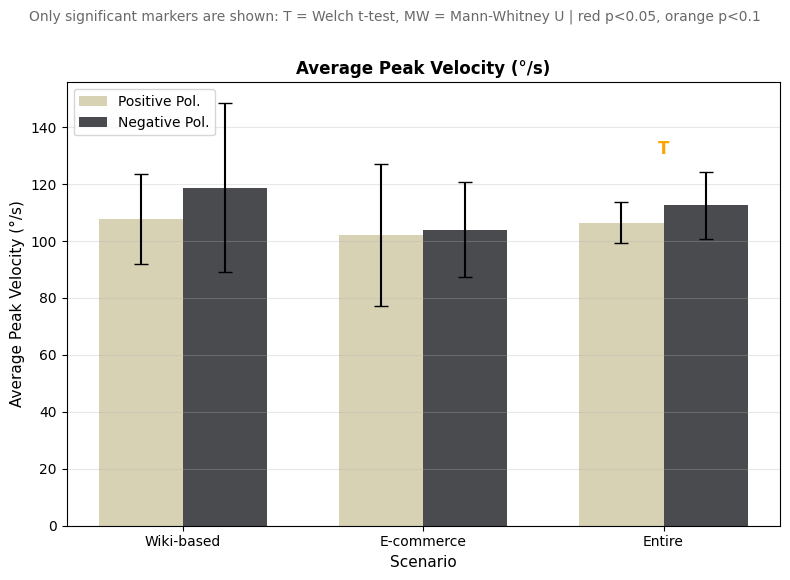

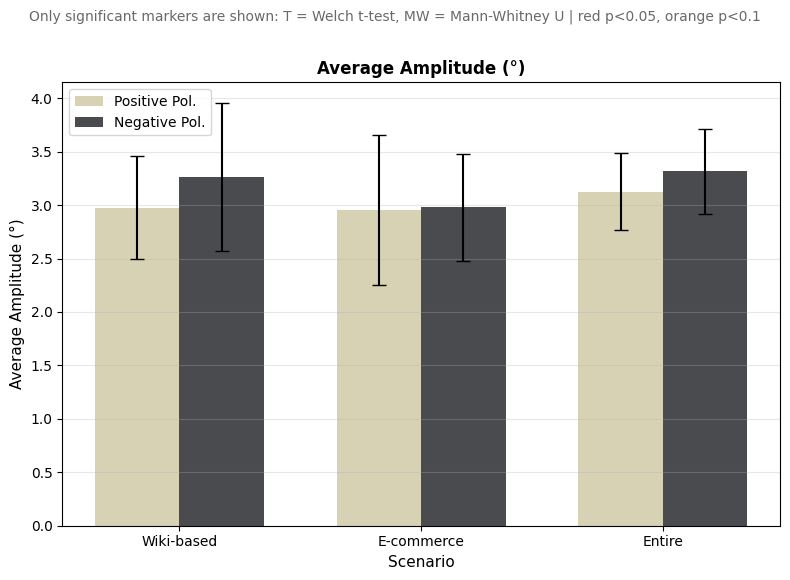

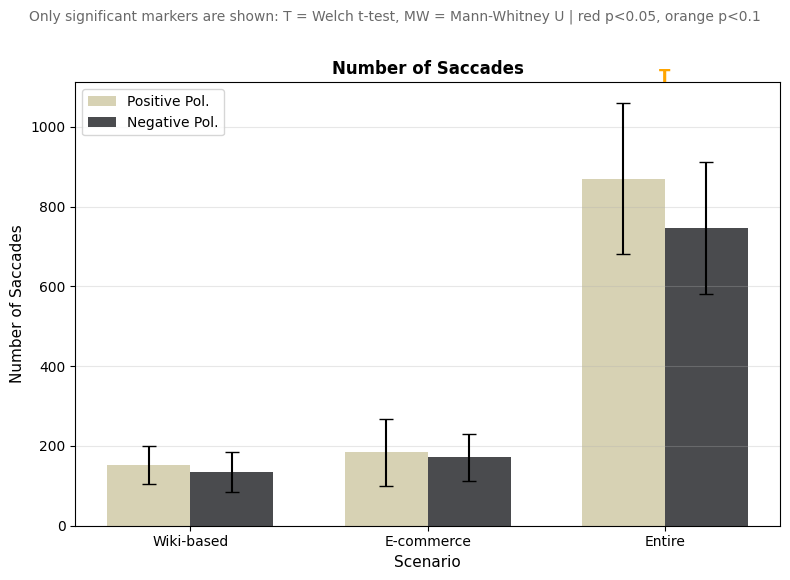

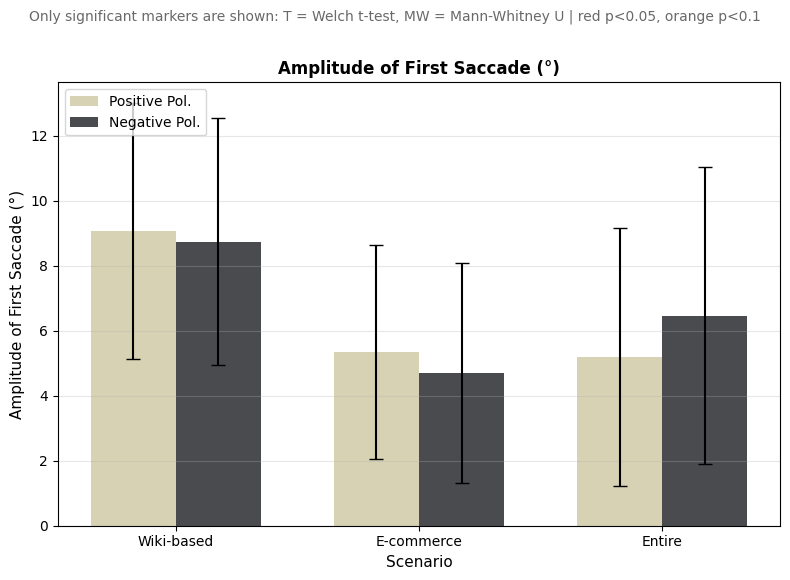

In [23]:


metric_keys = [
    'Average_peak_velocity_of_saccades',
    'Average_amplitude_of_saccades',
    'Number_of_saccades',
    'Amplitude_of_first_saccade',
]

metric_labels = [
    'Average Peak Velocity (°/s)',
    'Average Amplitude (°)',
    'Number of Saccades',
    'Amplitude of First Saccade (°)',
]
toi_labels = ['Wiki-based', 'E-commerce', 'Entire']

scenario_results = {
    'Wiki-based': {'T': patata_tstudent, 'MW': patata_mann_whitney},
    'E-commerce': {'T': mochila_tstudent, 'MW': mochila_mann_whitney},
    'Entire': {'T': entire_tstudent, 'MW': entire_mann_whitney},
}


for idx, metric in enumerate(metric_keys):
    fig, ax = plt.subplots(figsize=(8, 6))

    claro_means = [
        basic_data_saccades['PatataClaro'][idx][0],
        basic_data_saccades['MochilaClaro'][idx][0],
        basic_data_saccades['EntireClaro'][idx][0],
    ]
    claro_stds = [
        basic_data_saccades['PatataClaro'][idx][1],
        basic_data_saccades['MochilaClaro'][idx][1],
        basic_data_saccades['EntireClaro'][idx][1],
    ]
    oscuro_means = [
        basic_data_saccades['PatataOscuro'][idx][0],
        basic_data_saccades['MochilaOscuro'][idx][0],
        basic_data_saccades['EntireOscuro'][idx][0],
    ]
    oscuro_stds = [
        basic_data_saccades['PatataOscuro'][idx][1],
        basic_data_saccades['MochilaOscuro'][idx][1],
        basic_data_saccades['EntireOscuro'][idx][1],
    ]

    x = np.arange(len(toi_labels))
    width = 0.35

    ax.bar(
        x - width / 2,
        claro_means,
        width,
        yerr=claro_stds,
        label='Positive Pol.',
        color='#CEC7A2',
        alpha=0.8,
        capsize=5,
    )
    ax.bar(
        x + width / 2,
        oscuro_means,
        width,
        yerr=oscuro_stds,
        label='Negative Pol.',
        color='#1D1E22',
        alpha=0.8,
        capsize=5,
    )

    # Add marker only when result is relevant/significant (p < 0.1)
    for j, scenario in enumerate(toi_labels):
        y_pos = max(claro_means[j] + claro_stds[j], oscuro_means[j] + oscuro_stds[j])

        if metric in scenario_results[scenario]['T']:
            test_used = 'T'
            pvalue = scenario_results[scenario]['T'][metric].pvalue
        elif metric in scenario_results[scenario]['MW']:
            test_used = 'MW'
            pvalue = scenario_results[scenario]['MW'][metric].pvalue
        else:
            continue

        if pvalue >= 0.1:
            continue

        color = 'red' if pvalue < 0.05 else 'orange'
        ax.text(
            x[j],
            y_pos * 1.05,
            test_used,
            ha='center',
            fontsize=12,
            fontweight='bold',
            color=color,
        )

    ax.set_xlabel('Scenario', fontsize=11)
    ax.set_ylabel(metric_labels[idx], fontsize=11)
    ax.set_title(metric_labels[idx], fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(toi_labels)
    ax.legend(loc='upper left')
    ax.grid(axis='y', alpha=0.3)

    fig.text(
        0.5,
        0.94,
        'Only significant markers are shown: T = Welch t-test, MW = Mann-Whitney U | red p<0.05, orange p<0.1',
        ha='center',
        fontsize=10,
        color='dimgray',
    )
    plt.tight_layout(rect=[0, 0, 1, 0.90])


    fig.savefig(f'output/figures/{metric}.png', dpi=300, bbox_inches='tight')


    plt.show()